# A low-level Gaussian Process API

This notebook walks through a proof-of-concept GP API built on one idea:

> **A GP prior is an `MvNormal` over packed inputs. Everything else is generic
> linear-Gaussian machinery that knows nothing about GPs.**

Concretely:

| Concept | What it actually is |
|---|---|
| GP prior | `pm.MvNormal(mu, K)` where `K = kernel(X)` |
| Partition (train / predict / inducing) | `pt.pack` + `pt.unpack` — a slice |
| Marginalizing the latent | `pymc_extras.marginalize` |
| Predictive distribution | `pymc_extras.conditional` |
| Sparse approximation (DTC/FITC) | a linear map `A @ u` of a smaller GP |
| Variational (SVGP) | the existing ADVI full-rank guide over `u` |

The only new machinery is a **linear-Gaussian conjugacy rewrite**: for
`f ~ MvNormal(m, K)` and `y ~ Normal(g(f), s)` with `g` affine,

$$y \sim \mathcal{N}(Am + b,\; AKA^\top + S), \qquad
f \mid y \sim \mathcal{N}\big(m + (AK)^\top G^{-1} r,\; K - (AK)^\top G^{-1}(AK)\big)$$

with $G = AKA^\top + S$ and $r = y - (Am+b)$. It registers into
`marginal_ir_rewrites_db`, and both `marginalize` and `conditional` then work
unmodified. It is not GP-specific — it also covers linear regression
coefficients, Kalman filters, and any other linear-Gaussian latent.

Because `g` is *any* affine function, "observed at a subset of the inputs" and
"projected onto the data from inducing points" are the same mechanism.

---

*This notebook is generated. Edit `gp_api_build.py` (the single source of truth
for both prose and code) and regenerate with `python gp_api_build.py`, then
`python gp_api_execute.py` to re-run it and embed outputs. Editing the `.ipynb`
directly will be silently overwritten on the next regeneration.*

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
import pytensor.tensor as pt

import pymc_extras.gp as pgp

RNG = np.random.default_rng(0)
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## The data

A noisy sine, 60 training points on `[0, 1]`. We predict on a grid that extends
past the data on both sides, so the prior takes over at the edges.

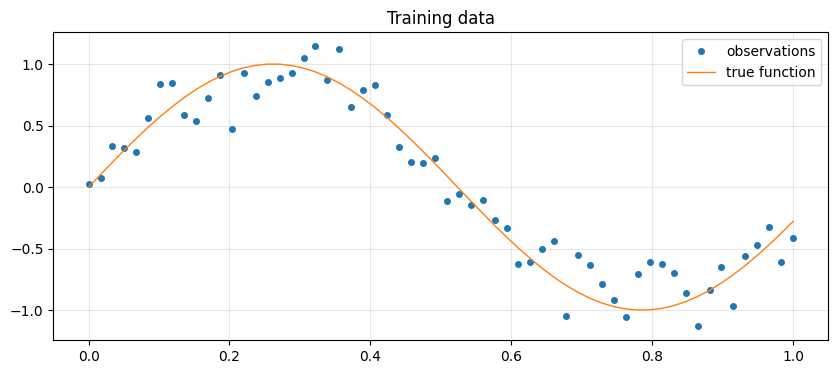

In [2]:
N_TRAIN = 60
X = np.linspace(0, 1, N_TRAIN)[:, None]
y = np.sin(6 * X.ravel()) + 0.2 * RNG.normal(size=N_TRAIN)

X_pred = np.linspace(-0.3, 1.3, 80)[:, None]

fig, ax = plt.subplots()
ax.plot(X.ravel(), y, "o", ms=4, label="observations")
ax.plot(X.ravel(), np.sin(6 * X.ravel()), lw=1, label="true function")
ax.legend()
ax.set_title("Training data")
plt.show()

## 1. Kernels

Kernels are **callable objects, not matrices**. `k(X)` is the covariance and
`k(X, Xs)` the cross-covariance. Keeping the function rather than freezing a
matrix is what lets the model be re-evaluated at new inputs later.

They compose with `+` and `*`, and scale by scalars — including model random
variables, which is how hyperpriors enter.

k(X)      -> (60, 60)
k(X, Xs)  -> (60, 80)  (cross-covariance is rectangular)


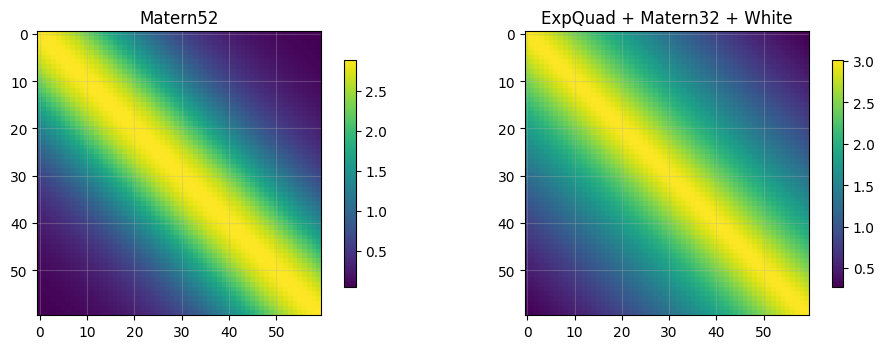

In [3]:
k = 1.7**2 * pgp.kernels.Matern52(ls=0.3)

print("k(X)      ->", k(X).eval().shape)
print("k(X, Xs)  ->", k(X, X_pred).eval().shape, " (cross-covariance is rectangular)")

# composition, ARD, and a nugget
k_composite = (
    2.0 * pgp.kernels.ExpQuad(ls=np.array([0.5]))
    + pgp.kernels.Matern32(ls=0.2)
    + pgp.kernels.WhiteNoise(0.1)
)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for ax, kern, name in zip(axes, [k, k_composite], ["Matern52", "ExpQuad + Matern32 + White"]):
    im = ax.imshow(kern(X).eval(), cmap="viridis")
    ax.set_title(name)
    fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

## 2. The GP prior, and packing

The prior is defined **jointly over every input set we care about** — here the
training points and the prediction grid, stacked. `pt.pack` does the stacking
and hands back `packed_shapes`; `pt.unpack` splits any value that shares that
leading axis.

This is the key structural move. `gp` is a single `MvNormal` of length
`n_train + n_pred`, and "observed at the training points" is `f_train`, a plain
slice. Slicing is affine, which is all the marginalization needs.

The only real constraint is that **the prediction inputs must be part of the
joint prior at build time**. They do not have to be a `pm.Data`: here `X_pred`
is an ordinary array, which is the common case when you know where you want
predictions before fitting.

`packed_shapes` are symbolic graphs rather than plain sizes. With ordinary
arrays they fold to constants, so the same `shapes` can be reused anywhere,
including after `marginalize` / `conditional` (section 4 does exactly that).

If you instead want to move the prediction grid *without rebuilding the model*,
make it a `pm.Data` and `set_data` it. Then `packed_shapes` reference that
shared variable, and since every pymc model transform goes through
`clone_model` -- which clones shared variables -- you must re-derive them
against the transformed model:

    _, shp = pt.pack(X, cond_m["X_pred"], keep_axes=-1)

Reusing the originals silently slices by the pre-transform length: wrong
result, no error. The upside is that `set_data` may then change the *number* of
prediction points, not just their positions. (Both behaviours are covered in
`tests/gp/test_gp_api.py`; this notebook sticks to the fixed-grid case.)

In [4]:
ETA_TRUE, LS_TRUE, SIGMA_TRUE = 1.7, 0.3, 0.2

with pm.Model() as latent_model:
    ls = pm.InverseGamma("ls", alpha=3.0, beta=1.0)
    eta = pm.Exponential("eta", scale=1.0)
    sigma = pm.HalfNormal("sigma", sigma=1.0)

    Xs, shapes = pt.pack(X, X_pred, keep_axes=-1)  # -> (n_train + n_pred, 1)
    kernel = eta**2 * pgp.kernels.Matern52(ls=ls)

    gp = pgp.GP("gp", Xs, cov=kernel)  # one MvNormal over every input
    f_train, f_pred = pt.unpack(gp, shapes)  # the partition

    pm.Normal("y", mu=f_train, sigma=sigma, observed=y)

print("packed inputs :", Xs.type.shape)
print("gp            :", gp.type.shape)
print("f_train       :", f_train.type.shape)
print("f_pred        :", f_pred.type.shape)
print("free_RVs      :", [v.name for v in latent_model.free_RVs])

packed inputs : (140, 1)
gp            : (140,)
f_train       : (60,)
f_pred        : (80,)
free_RVs      : ['ls', 'eta', 'sigma', 'gp']


## 3. Exact marginalization

With a Gaussian likelihood the latent GP integrates out in closed form. Note
this is the *generic* `marginalize` from `pymc_extras` — there is no GP-specific
code path.

After marginalizing, `gp` is gone and only the hyperparameters remain, so NUTS
samples a 3-dimensional posterior instead of a (3 + n_train + n_pred)-dimensional one.

In [5]:
marginal_model = pgp.marginalize(latent_model, ["gp"])

print("free_RVs before :", [v.name for v in latent_model.free_RVs])
print("free_RVs after  :", [v.name for v in marginal_model.free_RVs])

# the marginal likelihood is exactly N(0, K_train + sigma^2 I)
point = marginal_model.initial_point()
print("\nmarginal logp at initial point:", float(marginal_model.compile_logp()(point)))

free_RVs before : ['ls', 'eta', 'sigma', 'gp']
free_RVs after  : ['sigma', 'ls', 'eta']



marginal logp at initial point: -64.65879428824955


In [6]:
with marginal_model:
    idata = pm.sample(draws=400, tune=400, chains=2, random_seed=0, progressbar=False)

import arviz as az

print(az.summary(idata, var_names=["ls", "eta", "sigma"], round_to=3))
print("\ntrue values: ls =", LS_TRUE, " eta =", ETA_TRUE, " sigma =", SIGMA_TRUE)
print(
    "\nNote: sigma and ls are recovered well. eta is only weakly identified by a GP\n"
    "marginal likelihood -- it trades off against ls -- and the Exponential(1) prior\n"
    "pulls it toward small amplitudes. That is a property of the model, not of the\n"
    "marginalization machinery."
)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [sigma, ls, eta]


Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 93 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


        mean     sd  eti89_lb  eti89_ub  ess_bulk  ess_tail  r_hat  mcse_mean  \
ls     0.325  0.105     0.193     0.504   338.575   319.198  1.004      0.006   
eta    0.874  0.408     0.448     1.637   382.509   344.673  1.004      0.025   
sigma  0.167  0.018     0.141     0.198   442.282   450.371  1.004      0.001   

       mcse_sd  
ls       0.007  
eta      0.033  
sigma    0.001  

true values: ls = 0.3  eta = 1.7  sigma = 0.2

Note: sigma and ls are recovered well. eta is only weakly identified by a GP
marginal likelihood -- it trades off against ls -- and the Exponential(1) prior
pulls it toward small amplitudes. That is a property of the model, not of the
marginalization machinery.


## 4. The conditional — predictions

`conditional` returns a **`pm.Model`**, not a distribution and not a function.
In it, the marginalized variable is back as a free RV whose *distribution is the
conditional* $p(\text{gp} \mid y, \theta)$ — a plain `MvNormal` whose `mu` and
`cov` are still symbolic in the hyperparameters.

Where does `X_pred` enter? Only through the cross-covariance
$K[\text{train}, \text{pred}]$ and the prior block $K[\text{pred}, \text{pred}]$.
It never touches $G$, the matrix that actually gets factorized — which is why
changing the prediction grid does not affect the fit.

In [7]:
cond_model = pgp.conditional(marginal_model)

print("free_RVs:", [v.name for v in cond_model.free_RVs], " <- gp is back")
f = cond_model["gp"]
print("gp distribution:", type(f.owner.op).__name__)

mu_sym, cov_sym = pgp.conditional_moments(cond_model)
print("conditional mu :", mu_sym.type.shape)
print("conditional cov:", cov_sym.type.shape)

free_RVs: ['eta', 'ls', 'sigma', 'gp']  <- gp is back
gp distribution: MvNormalRV
conditional mu : (140,)
conditional cov: (140, 140)


In [8]:
# Compile predictive moments as a function of a posterior point.
_, mu_pred_sym = pt.unpack(mu_sym, shapes)
_, sd_pred_sym = pt.unpack(pt.sqrt(pt.diag(cov_sym)), shapes)

predictive = pgp.predictive_fn(cond_model, [mu_pred_sym, sd_pred_sym])

post = idata.posterior.to_dataset().stack(sample=("chain", "draw"))
means, sds = [], []
for i in range(0, post.sizes["sample"], 20):  # thin for speed
    s = post.isel(sample=i)
    m_, sd_ = predictive(
        {
            "ls_log__": float(np.log(s["ls"])),
            "eta_log__": float(np.log(s["eta"])),
            "sigma_log__": float(np.log(s["sigma"])),
        }
    )
    means.append(m_)
    sds.append(sd_)

means, sds = np.array(means), np.array(sds)

# marginalize over the hyperparameter posterior (law of total variance)
mean_pred = means.mean(0)
sd_pred = np.sqrt(sds.mean(0) ** 2 + means.var(0))

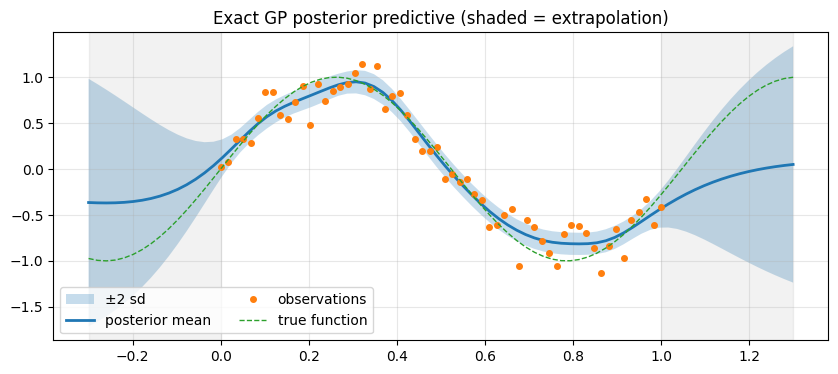

In [9]:
xg = X_pred.ravel()
fig, ax = plt.subplots()
ax.fill_between(xg, mean_pred - 2 * sd_pred, mean_pred + 2 * sd_pred, alpha=0.25, label="±2 sd")
ax.plot(xg, mean_pred, lw=2, label="posterior mean")
ax.plot(X.ravel(), y, "o", ms=4, label="observations")
ax.plot(xg, np.sin(6 * xg), lw=1, ls="--", label="true function")
ax.axvspan(-0.3, 0, color="k", alpha=0.05)
ax.axvspan(1.0, 1.3, color="k", alpha=0.05)
ax.set_title("Exact GP posterior predictive (shaded = extrapolation)")
ax.legend(loc="lower left", ncols=2)
plt.show()

Uncertainty grows in the shaded extrapolation regions and collapses toward the
noise level where the data is dense — the expected GP behaviour, obtained
without any GP-specific inference code.

You can also just draw from it:

Sampling: [gp]


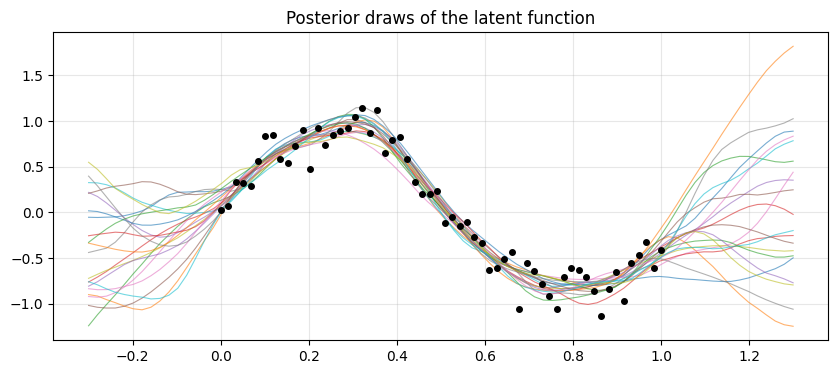

In [10]:
with cond_model:
    pp = pm.sample_posterior_predictive(idata, var_names=["gp"], random_seed=0, progressbar=False)

draws = pp.posterior_predictive["gp"].to_numpy().reshape(-1, len(X) + len(X_pred))
_, draws_pred = np.split(draws, [len(X)], axis=1)

fig, ax = plt.subplots()
ax.plot(xg, draws_pred[::40].T, lw=0.8, alpha=0.6)
ax.plot(X.ravel(), y, "o", ms=4, color="k")
ax.set_title("Posterior draws of the latent function")
plt.show()

### Predicting at inputs chosen *after* fitting

Above, the prediction grid was an ordinary array fixed when the model was
built. To move it without rebuilding, make it a `pm.Data`.

The one wrinkle: every pymc model transform goes through `clone_model`, which
clones shared variables, so `cond_model["X_pred"]` is a *different object* from
the `X_pred` we packed. `packed_shapes` built from the original would keep
reading the original model's data and silently slice by the pre-transform
length. Re-derive them by name against the transformed model.

In [11]:
with pm.Model() as data_model:
    X_pred_data = pm.Data("X_pred", X_pred)  # mutable prediction block
    Xs_d, _ = pt.pack(X, X_pred_data, keep_axes=-1)
    gp_d = pgp.GP("gp", Xs_d, cov=ETA_TRUE**2 * pgp.kernels.Matern52(ls=LS_TRUE))
    f_train_d, _ = pt.unpack(gp_d, pt.pack(X, X_pred_data, keep_axes=-1)[1])
    pm.Normal("y", mu=f_train_d, sigma=SIGMA_TRUE, observed=y)

cond_data = pgp.conditional(pgp.marginalize(data_model, ["gp"]))
mu_d, cov_d = pgp.conditional_moments(cond_data)


def predict_at(X_new):
    # predictive mean and sd at arbitrary new inputs, no refitting
    with cond_data:
        pm.set_data({"X_pred": X_new})
    # re-derive the layout against the TRANSFORMED model's Data, not the original
    _, shp = pt.pack(X, cond_data["X_pred"], keep_axes=-1)
    mean = pt.unpack(mu_d, shp)[1].eval()
    sd = pt.unpack(pt.sqrt(pt.diag(cov_d)), shp)[1].eval()
    return mean, sd


grid_wide = np.linspace(-0.3, 1.3, 80)[:, None]
grid_zoom = np.linspace(0.35, 0.65, 25)[:, None]  # different range AND count

m_wide, s_wide = predict_at(grid_wide)
m_zoom, s_zoom = predict_at(grid_zoom)

print("wide grid:", m_wide.shape, " zoomed grid:", m_zoom.shape)

wide grid: (80,)  zoomed grid: (25,)


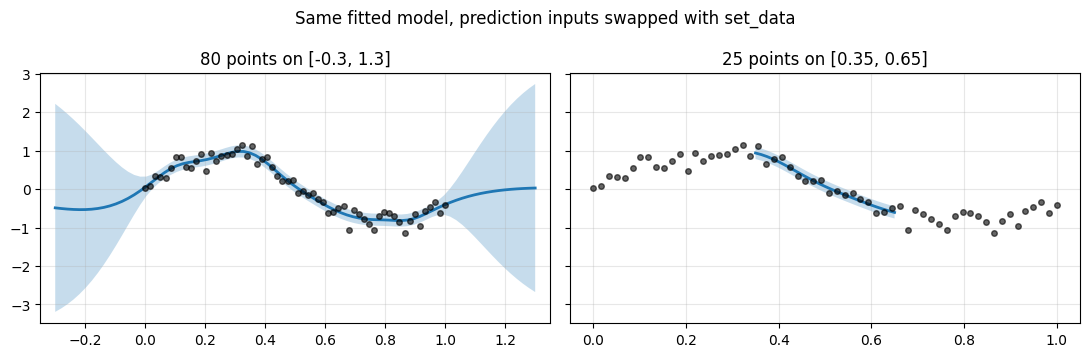

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, g, mu_, sd_, title in [
    (axes[0], grid_wide.ravel(), m_wide, s_wide, "80 points on [-0.3, 1.3]"),
    (axes[1], grid_zoom.ravel(), m_zoom, s_zoom, "25 points on [0.35, 0.65]"),
]:
    ax.fill_between(g, mu_ - 2 * sd_, mu_ + 2 * sd_, alpha=0.25)
    ax.plot(g, mu_, lw=2)
    ax.plot(X.ravel(), y, "o", ms=4, color="k", alpha=0.6)
    ax.set_title(title)
axes[0].set_xlim(-0.35, 1.35)
fig.suptitle("Same fitted model, prediction inputs swapped with set_data")
plt.tight_layout()
plt.show()

Both the *locations* and the *number* of prediction points changed with no
refit: the fitted quantity is `G = A K A' + S`, which only involves the
training block, so `set_data` on `X_pred` cannot touch it.

## 5. Sparsity induction — inducing points

A sparse GP puts the prior on a small set of **inducing inputs** $Z$ and pushes
it onto the data with a linear map:

$$u \sim \mathcal{N}(0, K_{zz}), \qquad f = A u, \quad A = K_{xz}K_{zz}^{-1}$$

Because $A u$ is *affine in $u$*, this needs **no approximation-specific
machinery** — the same conjugacy rewrite handles it. `project` builds $A u$.

Two standard variants:

* **DTC** — use $f = Au$ directly.
* **FITC** — add back the discarded marginal variance
  $\mathrm{diag}(K_{xx} - Q_{xx})$ to the observation noise. That's
  `prior_variance_correction`, and it enters the *noise*, which the rewrite
  requires to be latent-independent.

In [13]:
N_INDUCING = 12
Z = np.linspace(0, 1, N_INDUCING)[:, None]


def sparse_model(fitc: bool):
    with pm.Model() as m:
        kern = ETA_TRUE**2 * pgp.kernels.Matern52(ls=LS_TRUE)
        u = pgp.GP("u", Z, cov=kern)  # only 12 latent values
        f = pgp.project(u, X)  # A @ u  -> affine
        noise = SIGMA_TRUE
        if fitc:
            noise = pt.sqrt(SIGMA_TRUE**2 + pgp.prior_variance_correction(u, X))
        pm.Normal("y", mu=f, sigma=noise, observed=y)
    return m


for name, fitc in [("DTC ", False), ("FITC", True)]:
    mm = pgp.marginalize(sparse_model(fitc), ["u"])
    print(
        f"{name}  latent dim = {N_INDUCING:3d}   marginal logp = {float(mm.compile_logp()({})):9.4f}"
    )

# exact GP for reference, same hyperparameters
with pm.Model() as exact_m:
    kern = ETA_TRUE**2 * pgp.kernels.Matern52(ls=LS_TRUE)
    gp_e = pgp.GP("gp", X, cov=kern)
    pm.Normal("y", mu=gp_e, sigma=SIGMA_TRUE, observed=y)
print(
    f"exact latent dim = {N_TRAIN:3d}   marginal logp = "
    f"{float(pgp.marginalize(exact_m, ['gp']).compile_logp()({})):9.4f}"
)

DTC   latent dim =  12   marginal logp =    3.8290


FITC  latent dim =  12   marginal logp =    3.6786
exact latent dim =  60   marginal logp =    3.6721


FITC tracks the exact marginal likelihood far more closely than DTC, which is
the textbook result — it restores the marginal variances that the rank-12
projection throws away.

A useful sanity check: setting `Z = X` should collapse FITC back to the exact GP.

In [14]:
with pm.Model() as m_zx:
    kern = ETA_TRUE**2 * pgp.kernels.Matern52(ls=LS_TRUE)
    u = pgp.GP("u", X, cov=kern, jitter=1e-12)  # inducing points == data
    corr = pgp.prior_variance_correction(u, X, jitter=1e-12)
    pm.Normal(
        "y", mu=pgp.project(u, X, jitter=1e-12), sigma=pt.sqrt(SIGMA_TRUE**2 + corr), observed=y
    )

fitc_zx = float(pgp.marginalize(m_zx, ["u"]).compile_logp()({}))
exact = float(pgp.marginalize(exact_m, ["gp"]).compile_logp()({}))
print(f"FITC with Z = X : {fitc_zx:.6f}")
print(f"exact GP        : {exact:.6f}")
print(f"difference      : {abs(fitc_zx - exact):.2e}   (solver jitter)")

FITC with Z = X : 3.672346
exact GP        : 3.672113
difference      : 2.33e-04   (solver jitter)


### ⚠️ Correct, but not yet *cheap*

Sparse GPs here are numerically right but do **not** get the $O(nm^2)$ speedup.
The rewrite forms $AKA^\top$ densely and Choleskys an $n \times n$ matrix,
reconstructing the full-rank problem it was meant to avoid.

Getting the asymptotic win requires keeping the covariance **structured**
(low-rank + diagonal) so the logp can use the Woodbury identity. That is the
main outstanding work item, and it is the same work that low-rank ADVI needs.

In [15]:
import time

print("marginal logp cost, 12 inducing points, live hyperparameters:\n")
for n in (250, 500, 1000, 2000):
    Xn = np.linspace(0, 1, n)[:, None]
    yn = np.sin(6 * Xn.ravel()) + 0.2 * RNG.normal(size=n)
    with pm.Model() as mt:
        ls_ = pm.HalfNormal("ls", 1.0)
        eta_ = pm.HalfNormal("eta", 1.0)
        u = pgp.GP("u", Z, cov=eta_**2 * pgp.kernels.Matern52(ls=ls_))
        pm.Normal("y", mu=pgp.project(u, Xn), sigma=0.2, observed=yn)
    mm = pgp.marginalize(mt, ["u"])
    fn, p = mm.compile_logp(), mm.initial_point()
    fn(p)
    t0 = time.perf_counter()
    for _ in range(3):
        fn(p)
    print(f"  n = {n:5d}   {(time.perf_counter() - t0) / 3 * 1000:7.2f} ms")
print("\n~4-5x per doubling => O(n^2.3), i.e. dense. Woodbury would make this linear in n.")

marginal logp cost, 12 inducing points, live hyperparameters:



  n =   250      0.80 ms


  n =   500      3.77 ms


  n =  1000     20.03 ms


  n =  2000     91.10 ms

~4-5x per doubling => O(n^2.3), i.e. dense. Woodbury would make this linear in n.


## 6. Variational inference (SVGP)

SVGP does **not** go through `marginalize` — it is a *guide plus an ELBO*. But
it needs no new machinery either, because

$$\mathrm{ELBO} = \mathbb{E}_{q(u)}\big[\log p(y \mid Au)\big] - \mathrm{KL}\big(q(u)\,\|\,p(u)\big)$$

is exactly what `E_q[log p(y, u) - log q(u)]` computes when `p(u)` is in the
model and `q(u)` is a full-rank guide. **You never implement the KL term** — it
is the `log p(u) - log q(u)` part of the standard ADVI objective.

So: *SVGP is the stock `Trainer` with an `AutoMultivariateNormal` guide, applied
to a model whose latent is the inducing values.* No SVGP-specific code at all —
the only GP-aware line is `project`, which is shared with the sparse section
above.

/home/ricardo/Documents/.pymc-extras-worktree2/.venv/lib64/python3.13/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

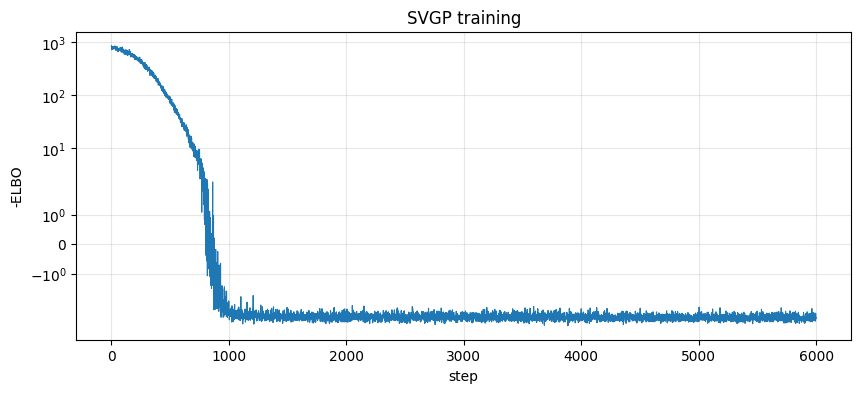

steps run  : 6000
final -ELBO: -3.8122


In [16]:
from pymc_extras.inference.advi import AutoMultivariateNormal, Trainer

svgp_model = sparse_model(fitc=False)  # DTC + Gaussian likelihood

trainer = Trainer(
    guide=AutoMultivariateNormal,  # full-rank q(u) -- this is what makes it SVGP
    model=svgp_model,
    n_particles=64,  # guide draws per ELBO gradient estimate
    convergence_window=None,  # run the full budget so the curve is comparable
    random_seed=0,
)
state = trainer.fit(6000)

loss = np.asarray(state.loss_history)
fig, ax = plt.subplots()
ax.plot(loss, lw=0.8)
ax.set_yscale("symlog")
ax.set_xlabel("step")
ax.set_ylabel("-ELBO")
ax.set_title("SVGP training")
plt.show()

print("steps run  :", state.step)
print("final -ELBO:", round(float(loss[-1]), 4))

### Does it find the right answer?

With a conjugate likelihood the true posterior over `u` **is** Gaussian, so the
variational family contains the exact optimum. That means we can check VI
against the closed-form answer from the `marginalize` / `conditional` path —
two independent halves of the design that should agree.

q(u) mean vs exact : max|diff| = 0.0012   (scale 0.921)
q(u) cov  vs exact : max|diff| = 0.0002   (scale 0.017)


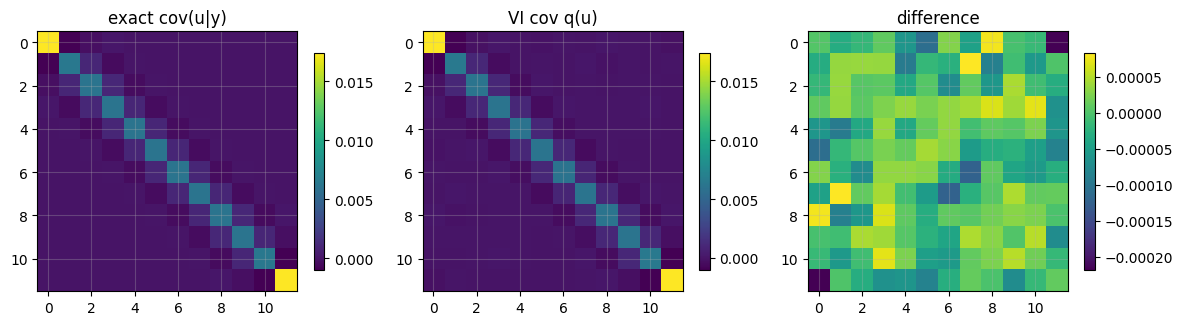

In [17]:
# closed-form posterior over u
cond_u = pgp.conditional(pgp.marginalize(sparse_model(fitc=False), ["u"]))
mu_exact, cov_exact = (v.eval() for v in pgp.conditional_moments(cond_u, "u"))

# unpack the guide's variational parameters
params = {k: np.asarray(v) for k, v in state.params.items()}
loc = params["loc"]
nd = loc.size
L = np.zeros((nd, nd))
L[np.tril_indices(nd)] = params["L_packed"]
L[np.diag_indices(nd)] = np.log1p(np.exp(np.diag(L)))  # softplus diagonal
cov_vi = L @ L.T

print(
    f"q(u) mean vs exact : max|diff| = {np.abs(loc - mu_exact).max():.4f}"
    f"   (scale {np.abs(mu_exact).max():.3f})"
)
print(
    f"q(u) cov  vs exact : max|diff| = {np.abs(cov_vi - cov_exact).max():.4f}"
    f"   (scale {np.abs(cov_exact).max():.3f})"
)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
for ax, M, t in zip(
    axes, [cov_exact, cov_vi, cov_vi - cov_exact], ["exact cov(u|y)", "VI cov q(u)", "difference"]
):
    im = ax.imshow(M, cmap="viridis")
    ax.set_title(t)
    fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

### Predicting from `q(u)`

Prediction reuses the *same* linear map. Since $f_* = A_* u$ is affine and
$q(u)$ is Gaussian, the predictive pushes through in closed form:

$$q(f_*) = \mathcal{N}\big(A_*\,\mathrm{loc},\;\; A_*\,\Sigma_q\,A_*^\top\big)$$

No sampling needed. `project` builds $A_* u$ inside a model; here we build
$A_*$ explicitly to show what it is.

A_star: (80, 12)


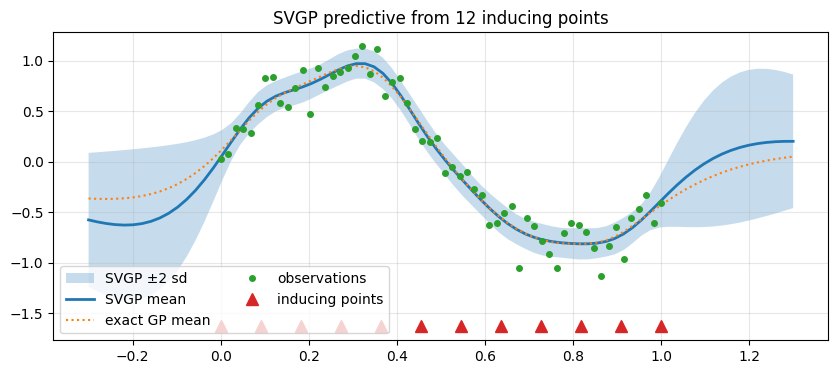

In [18]:
kern_fixed = ETA_TRUE**2 * pgp.kernels.Matern52(ls=LS_TRUE)
Kzz = kern_fixed(Z) + 1e-6 * pt.eye(N_INDUCING)
Kzx = kern_fixed(X_pred, Z).T

A_star = pt.linalg.solve(Kzz, Kzx, assume_a="pos").T.eval()  # (n_pred, n_inducing)
print("A_star:", A_star.shape)

f_mean = A_star @ loc
f_cov = A_star @ cov_vi @ A_star.T
f_sd = np.sqrt(np.diag(f_cov))

fig, ax = plt.subplots()
ax.fill_between(xg, f_mean - 2 * f_sd, f_mean + 2 * f_sd, alpha=0.25, label="SVGP ±2 sd")
ax.plot(xg, f_mean, lw=2, label="SVGP mean")
ax.plot(xg, mean_pred, lw=1.5, ls=":", label="exact GP mean")
ax.plot(X.ravel(), y, "o", ms=4, label="observations")
ax.plot(Z.ravel(), np.full(N_INDUCING, y.min() - 0.5), "^", ms=9, label="inducing points")
ax.set_title(f"SVGP predictive from {N_INDUCING} inducing points")
ax.legend(loc="lower left", ncols=2)
plt.show()

## 7. What is still missing

This POC covers the model-side design end to end, but is not production-ready.
In rough priority order:

1. **Woodbury / structured covariance.** The blocker. Sparse GPs are correct but
   scale like $O(n^{2.3})$ because $AKA^\top$ is densified. Fixing this is the
   same work item as low-rank ADVI guides.
2. **Non-conjugate predictions.** `marginalize(..., laplace_approx={...})` gives
   an approximate marginal likelihood for e.g. a Bernoulli likelihood, but
   `conditional` raises `NotImplementedError` on a `MarginalLaplaceRV` — so
   there is no predictive path through that route yet. Sampling the latent
   directly still works.
3. **Minibatching** for SVGP — `pm.Minibatch` plus `total_size` rescaling of the
   expectation term. The ADVI refactor added and then reverted minibatch
   streaming through `Trainer.fit`, so this is in flight rather than absent.
4. **Collapsed / quadrature bound.** The expectation over `u` above is plain
   reparameterized Monte Carlo. Real SVGP uses per-point marginals $q(f_i)$ with
   Gauss-Hermite quadrature, which has far lower gradient variance.
5. **Whitening** ($u = L_{zz}w$) for conditioning.
6. **Mean functions**, multi-output / batched GPs, and Kronecker structure.

### Design notes worth keeping

* `A` is **never materialized**. The linear map is applied with
  `vectorize_graph`, which preserves structure — a partition stays a `Subtensor`
  rather than becoming a dense selection matrix. This is why carrying 120
  prediction points costs nothing in the training logp: they are structurally
  present but numerically dead, and PyTensor prunes them.
* Affineness is checked by a conservative **op whitelist**. Anything
  unrecognized declines cleanly instead of silently producing a wrong logp.
* `pt.pack`'s `packed_shapes` are symbolic. Over ordinary arrays they fold to
  constants and travel freely; over a `pm.Data` they are model-bound and must
  be re-derived after `marginalize` / `conditional`, or they silently read the
  pre-transform data -- wrong length, no error.